# 💉 Vaccination Sentiment Analysis Challenge

### Objective

The aim of this project is to build a Natural Language Processing (NLP) model that predicts the sentiment of vaccination-related tweets.

The model will classify tweets into three categories:

- Negative sentiment (-1)
- Neutral sentiment (0)
- Positive sentiment (1)

### Workflow

1. Dataset Understanding
2. Exploratory Data Analysis (EDA)
3. Text Cleaning and Preprocessing
4. Feature Extraction
5. Machine Learning Modelling
6. Model Evaluation
7. Zindi Prediction Submission


In [ ]:
# Importing Required Libraries
import pandas as pd
import numpy as np
import re
import html
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error
import warnings
warnings.filterwarnings("ignore")

## Loading the Dataset

The challenge provides three files:

- Train.csv: Contains tweets with sentiment labels for model training.
- Test.csv: Contains unseen tweets where predictions will be generated.
- SampleSubmission.csv: Shows the required submission format for Zindi.

In [ ]:
# Load datasets
train = pd.read_csv("/content/Train.csv")
test = pd.read_csv("/content/Test.csv")

print("Training shape:", train.shape)
print("Testing shape:", test.shape)

Training shape: (10001, 4)
Testing shape: (5177, 2)


## Previewing the Dataset

A quick look at the first few rows helps us understand the structure and content of each dataset.

In [ ]:
print("Training Dataset")
display(train.head())

print("Testing Dataset")
display(test.head())


Training Dataset


,tweet_id,safe_text,label,agreement
0,CL1KWCMY,Me &amp; The Big Homie meanboy3000 #MEANBOY #M...,0.0,1.0
1,E3303EME,I'm 100% thinking of devoting my career to pro...,1.0,1.0
2,M4IVFSMS,"#whatcausesautism VACCINES, DO NOT VACCINATE Y...",-1.0,1.0
3,1DR6ROZ4,I mean if they immunize my kid with something ...,-1.0,1.0
4,J77ENIIE,Thanks to <user> Catch me performing at La Nui...,0.0,1.0


Testing Dataset


,tweet_id,safe_text
0,00BHHHP1,<user> <user> ... &amp; 4 a vaccine given 2 he...
1,00UNMD0E,Students starting school without whooping coug...
2,01AXPTJF,"I'm kinda over every ep of <user> being ""rippe..."
3,01HOEQJW,How many innocent children die for lack of vac...
4,01JUKMAO,"CDC eyeing bird flu vaccine for humans, though..."


## **Key Variables**
The primary variables used in this challenge are:

| Variable       | Description                                                                                                                                                                                                                                    |
| -------------- | ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **tweet_id**   | Unique identifier assigned to each tweet.                                                                                                                                                                                                      |
| **safe_tweet** | The tweet text after sensitive information such as usernames and URLs has been removed. This is the primary input feature for the model.                                                                                                       |
| **label**      | Sentiment label used for training, where **-1 = Negative**, **0 = Neutral**, and **1 = Positive**. This column is only available in the training dataset.                                                                                      |
| **agreement**  | Percentage of annotators who agreed on the assigned sentiment label. Higher values indicate greater confidence in the label. This variable is available only in the training data and may provide useful information during model development. |


## Dataset Structure

We inspect the available columns, data types, and missing values before beginning the analysis.

In [ ]:
# We will use  a function to  view our datasets structures
def dataset_summary(df, name):
  print(f"\n{'='*50}")
  print(f"{name} Dataset Summary")
  print(f"{'='*50}")

  print(f"Shape: {df.shape[0]} rows x {df.shape[1]} columns\n")

  print("Columns:")
  for col in df.columns:
    print(f"- {col}")

  print("\nData types:")
  print(df.dtypes)

  print("\nMissing values:")
  print(df.isnull().sum())


In [ ]:
dataset_summary(train, "Training")
dataset_summary(test, "Testing")


Training Dataset Summary
Shape: 10001 rows x 4 columns

Columns:
- tweet_id
- safe_text
- label
- agreement

Data types:
tweet_id      object
safe_text     object
label        float64
agreement    float64
dtype: object

Missing values:
tweet_id     0
safe_text    0
label        1
agreement    2
dtype: int64

Testing Dataset Summary
Shape: 5177 rows x 2 columns

Columns:
- tweet_id
- safe_text

Data types:
tweet_id     object
safe_text    object
dtype: object

Missing values:
tweet_id     0
safe_text    1
dtype: int64


In [ ]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10001 entries, 0 to 10000
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   tweet_id   10001 non-null  object 
 1   safe_text  10001 non-null  object 
 2   label      10000 non-null  float64
 3   agreement  9999 non-null   float64
dtypes: float64(2), object(2)
memory usage: 312.7+ KB


The training dataset contains 10,001 records and four variables, while the test dataset contains 5,177 records and two variables. Both datasets share the tweet_id and safe_text columns, with the training data additionally including the label and agreement variables. A few missing values were identified, which should be addressed during data preprocessing to ensure data quality before model training.

In [ ]:
#Inspect the first few rows

#Display the first five rows of the training dataset
print("Training Dataset")
display(train.head())

#Display the first five rows of the testing dataset
print("Testing Dataset")
display(test.head() )

Training Dataset


,tweet_id,safe_text,label,agreement
0,CL1KWCMY,Me &amp; The Big Homie meanboy3000 #MEANBOY #M...,0.0,1.0
1,E3303EME,I'm 100% thinking of devoting my career to pro...,1.0,1.0
2,M4IVFSMS,"#whatcausesautism VACCINES, DO NOT VACCINATE Y...",-1.0,1.0
3,1DR6ROZ4,I mean if they immunize my kid with something ...,-1.0,1.0
4,J77ENIIE,Thanks to <user> Catch me performing at La Nui...,0.0,1.0


Testing Dataset


,tweet_id,safe_text
0,00BHHHP1,<user> <user> ... &amp; 4 a vaccine given 2 he...
1,00UNMD0E,Students starting school without whooping coug...
2,01AXPTJF,"I'm kinda over every ep of <user> being ""rippe..."
3,01HOEQJW,How many innocent children die for lack of vac...
4,01JUKMAO,"CDC eyeing bird flu vaccine for humans, though..."


The preview confirms that each tweet is uniquely identified by a tweet_id, while the safe_text column contains the text that will be used for sentiment analysis. The training dataset also includes the label and agreement columns, which are absent from the test dataset as expected.

## Handling Missing Target Values

Since sentiment labels are required for supervised learning, rows without labels cannot be used for training.

In [ ]:
# Check missing values in the training and testing datasets
print("Missing Values in Training Dataset")
print(train.isnull().sum())

print("\nMissing Values in Testing Dataset")
print(test.isnull().sum())

Missing Values in Training Dataset
tweet_id     0
safe_text    0
label        1
agreement    2
dtype: int64

Missing Values in Testing Dataset
tweet_id     0
safe_text    1
dtype: int64


In [ ]:
# Handle missing values
train = train.dropna(subset=['label'])
test['safe_text'] = test['safe_text'].fillna("")

# Remove invalid label
train = train[train['label'].isin([-1, 0, 1])]

print("Updated training shape:", train.shape)

Updated training shape: (9999, 4)


## Understanding Sentiment Labels
Before building a model, it is important to examine the  distritbution of the target  vairable "Label" to understand how sentiment is spead across the dataset



In [ ]:
#Value counts of sentiment labels
print(train['label'].value_counts())

#Percentage distribution
print("\nPercentage distribution:")
print(train['label'].value_counts(normalize=True) * 100)

label
 0.0    4908
 1.0    4053
-1.0    1038
Name: count, dtype: int64

Percentage distribution:
label
 0.0    49.084908
 1.0    40.534053
-1.0    10.381038
Name: proportion, dtype: float64



The target variable represents the sentiment expressed in each tweet:

- -1 = Negative
- 0 = Neutral
- 1 = Positive

The dataset shows a moderate class imbalance, with neutral and positive sentiments dominating the distribution, while negative sentiment is underrepresented at approximately 10%. This imbalance may bias the model toward predicting neutral or positive sentiment more frequently, potentially reducing performance on negative cases.



In [ ]:
#remove the invalid label
train=train[train['label'].isin([-1,0,1])]

A single anomalous label value (0.6667) was identified, likely resulting from averaging multiple annotator opinions. Since the competition requires discrete sentiment labels (-1, 0, 1), this record was removed to maintain label consistency and prevent noise in model training.

**Text Length Analysis**
Text length can reveal patterns in how sentiment is expressed. For example, negative tweets may be longer due to explanations or complaints , while neutral tweets may be shorter  

In [ ]:
#Create text length feature
#Create a new feature: number of characters in each tweet:
train['text_length']=train["safe_text"].apply(len)

In [ ]:
#Summary statistics
print(train.groupby("label")["text_length"].describe())

        count        mean        std   min   25%    50%    75%    max
label                                                                
-1.0   1038.0  103.605010  27.424378  18.0  86.0  109.0  125.0  153.0
 0.0   4908.0   95.639772  31.529295   3.0  72.0  104.0  121.0  148.0
 1.0   4053.0  104.162102  27.591356  17.0  86.0  111.0  126.0  152.0


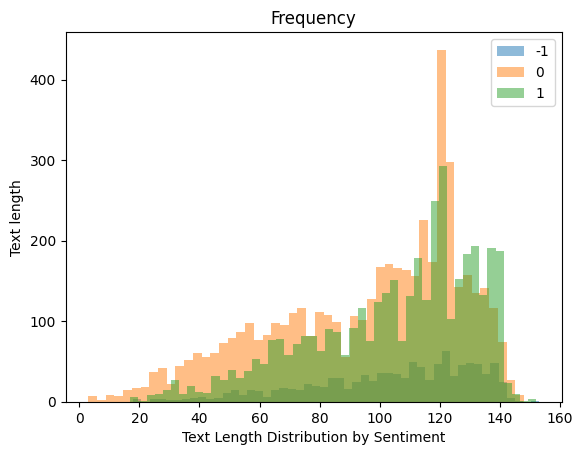

In [ ]:
#visualization
plt.figure()
for label in [-1,0,1]:
  subset=train[train["label"]==label]
  plt.hist(subset["text_length"],bins=50, alpha=0.5, label=str(label))

plt.legend()
plt.xlabel("Text Length Distribution by Sentiment")
plt.ylabel("Text length")
plt.title("Frequency")
plt.show()

In [ ]:
#average lengthe per sentiment
train.groupby("label")["text_length"].mean()

,text_length
label,
-1.0,103.605010
0.0,95.639772
1.0,104.162102


The analysis shows that the average tweet length varies slightly across sentiment classes. Negative tweets (-1) have an average length of approximately 103.6 characters, neutral tweets (0) are slightly shorter at around 95.6 characters, while positive tweets (1) have an average length of about 104.2 characters. The distributions are relatively similar across all classes, with overlapping ranges indicated by comparable quartiles and standard deviations

Text length shows minimal variation across sentiment classes, with heavy overlap in distributions. This indicates that tweet length is not a strong predictor of sentiment and should only be used as a supplementary feature alongside lexical representations such as TF-IDF or n-grams.

**Text Cleaning and Preprocessing **

\The text cleaning process involves preparing the tweet data for analysis by standardising and simplifying the raw text. This includes converting all text to lowercase, removing URLs and user mentions, and eliminating punctuation and special characters. The aim is to reduce noise in the data while preserving the meaningful linguistic content required for sentiment analysis.

In [ ]:
def improved_clean(text):
    if not isinstance(text, str):
        return ""

    text = html.unescape(str(text)).lower()
    text = re.sub(r'http\S+|www\.\S+', ' ', text)
    text = re.sub(r'@\w+', ' ', text)      # Keep mention placeholder
    text = re.sub(r'#(\w+)', r'\1', text)  # Keep hashtags content
    text = re.sub(r'[^a-z\s!?]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()

    tokens = [w for w in text.split() if w not in stopwords or w in ['not', 'no', 'never', 'anti']]
    return " ".join(tokens)

# Re-apply
train["clean_text"] = train["safe_text"].apply(improved_clean)
test["clean_text"] = test["safe_text"].apply(improved_clean)

## Comparing Raw and Cleaned Text

Comparing the original tweets with the cleaned version helps verify the preprocessing steps.

In [ ]:
train[["safe_text", "clean_text"]].head(10)


,safe_text,clean_text
0,Me &amp; The Big Homie meanboy3000 #MEANBOY #M...,big homie meanboy meanboy mb mbs mmr stegmanli...
1,I'm 100% thinking of devoting my career to pro...,m thinking devoting career proving autism isn ...
2,"#whatcausesautism VACCINES, DO NOT VACCINATE Y...",whatcausesautism vaccines not vaccinate child
3,I mean if they immunize my kid with something ...,mean immunize kid won t secretly kill years li...
4,Thanks to <user> Catch me performing at La Nui...,thanks user catch performing la nuit nyc st av...
5,<user> a nearly 67 year old study when mental ...,user nearly year old study mental health studi...
6,"Study of more than 95,000 kids finds no link b...",study kids finds no link mmr vaccine autism url
7,psa: VACCINATE YOUR FUCKING KIDS,psa vaccinate fucking kids
8,Coughing extra on the shuttle and everyone thi...,coughing extra shuttle thinks measles vaccinat...
9,AIDS vaccine created at Oregon Health &amp; Sc...,aids vaccine created oregon health science uni...


In [ ]:
train_working = train[["clean_text", "label"]].copy()
test_working = test[["tweet_id", "clean_text"]].copy()

In [ ]:
train_working.to_csv("train_clean.csv", index=False)
test_working.to_csv("test_clean.csv", index=False)

## Most Common Words in Tweets

Examining frequent words helps us understand the main topics appearing in vaccination-related tweets.

In [ ]:
print(train['label'].value_counts(normalize=True) * 100)

# Word frequency example
all_words = " ".join(train["clean_text"]).split()
print(Counter(all_words).most_common(20))

label
 0.0    49.084908
 1.0    40.534053
-1.0    10.381038
Name: proportion, dtype: float64
[('user', 5595), ('url', 4634), ('measles', 3448), ('vaccine', 1646), ('s', 1451), ('t', 1418), ('vaccines', 1288), ('kids', 1179), ('health', 1147), ('not', 1016), ('mmr', 998), ('vaccinate', 948), ('children', 855), ('people', 692), ('autism', 650), ('don', 638), ('outbreak', 586), ('vaccinated', 578), ('immunity', 567), ('no', 550)]


## Common Words in Positive Tweets

We explore which words appear most frequently in tweets with positive sentiment.

In [ ]:
positive_words = " ".join(
    train.loc[train["label"] == 1, "clean_text"]
)

Counter(positive_words.split()).most_common(20)

[('user', 2157),
 ('url', 1693),
 ('measles', 942),
 ('kids', 860),
 ('t', 806),
 ('vaccine', 768),
 ('vaccinate', 766),
 ('vaccines', 716),
 ('s', 635),
 ('children', 573),
 ('not', 563),
 ('don', 419),
 ('vaccinated', 393),
 ('autism', 392),
 ('health', 384),
 ('parents', 346),
 ('people', 330),
 ('vaccinations', 327),
 ('child', 309),
 ('no', 277)]

## Common Words in Negative Tweets

We explore which words appear most frequently in tweets with negative sentiment.

In [ ]:
negative_words = " ".join(
    train.loc[train["label"] == -1, "clean_text"]
)

Counter(negative_words.split()).most_common(20)

[('user', 828),
 ('url', 444),
 ('vaccines', 318),
 ('vaccine', 309),
 ('autism', 183),
 ('t', 173),
 ('not', 153),
 ('s', 131),
 ('measles', 112),
 ('kids', 111),
 ('children', 98),
 ('vaccinations', 86),
 ('no', 81),
 ('vaccinated', 75),
 ('vaccinate', 73),
 ('don', 73),
 ('cause', 69),
 ('cdcwhistleblower', 66),
 ('flu', 64),
 ('cdc', 63)]

## Cleaned Text Length

We calculate the number of words remaining after cleaning to understand how preprocessing affects the tweets.

In [ ]:
train["clean_word_count"] = (
    train["clean_text"]
    .apply(lambda x: len(x.split()))
)

train["clean_word_count"].describe()

,clean_word_count
count,9999.000000
mean,10.505151
std,3.286960
min,1.000000
25%,8.000000
50%,11.000000
75%,13.000000
max,23.000000


## Handling Empty Text Records

Some tweets became empty after preprocessing because they only contained removed elements such as URLs or user mentions.

These records cannot provide useful information for text classification, so they are replaced with a placeholder text.

In [ ]:
# Check empty processed tweets

empty_text = train[train["clean_text"].str.strip() == ""]

print("Empty tweets:", len(empty_text))

Empty tweets: 0


## Preparing Data for Modelling

The processed tweets are separated into input features and target labels.

The text will be transformed into numerical features, while the sentiment labels will be used for training the machine learning models.

In [ ]:
# Input text

X = train["clean_text"]


# Target sentiment

y = train["label"]


print("Features:", X.shape)

print("Target:", y.shape)

Features: (9999,)
Target: (9999,)


## Splitting Data for Model Training

The dataset is divided into training and validation sets.

The training data is used to teach the model patterns in text, while the validation data is used to evaluate how well the model performs on unseen tweets.

In [ ]:
from sklearn.model_selection import train_test_split


X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


print("Training samples:", X_train.shape)
print("Validation samples:", X_valid.shape)

Training samples: (7999,)
Validation samples: (2000,)


## Text Feature Extraction Using TF-IDF

Machine learning algorithms cannot directly understand text, so the processed tweets are converted into numerical features.

TF-IDF (Term Frequency-Inverse Document Frequency) gives higher importance to words that are meaningful in a tweet while reducing the influence of very common words.

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import FeatureUnion
from scipy.sparse import hstack

# Simpler but more generalizable vectorizer
word_tfidf = TfidfVectorizer(
    ngram_range=(1, 2),
    max_features=8000,
    min_df=5,
    max_df=0.85,
    sublinear_tf=True,
    stop_words='english'
)

char_tfidf = TfidfVectorizer(
    analyzer='char_wb',
    ngram_range=(3, 5),
    max_features=5000,
    min_df=8,
    sublinear_tf=True
)

tfidf = FeatureUnion([("word", word_tfidf), ("char", char_tfidf)])

X_text = tfidf.fit_transform(train["clean_text"])
agreement = train["agreement"].fillna(1.0).values.reshape(-1, 1)
X = hstack([X_text, agreement])

y = train["label"].values
weights = train["agreement"].fillna(1.0).values

X_train, X_valid, y_train, y_valid, w_train, _ = train_test_split(
    X, y, weights, test_size=0.2, random_state=42, stratify=y
)

print("New shape:", X.shape)

New shape: (9999, 9029)


## **Model Training: LightGBM**

To predict sentiment scores from vaccination-related tweets, we use LightGBM (Light Gradient Boosting Machine), a powerful gradient boosting framework. LightGBM is particularly effective for this task because it handles high-dimensional sparse data (like TF-IDF features) very well, captures complex non-linear patterns in the text, and supports sample weights (the agreement column).
Since our target is continuous (-1 to 1) and the evaluation metric is RMSE, LightGBM excels by iteratively building decision trees that minimize squared error while being computationally efficient and robust to overfitting through built-in regularization and early stopping.

In [ ]:
import lightgbm as lgb

train_data = lgb.Dataset(X_train, label=y_train, weight=w_train)
valid_data = lgb.Dataset(X_valid, label=y_valid, reference=train_data)

params = {
    'objective': 'regression',
    'metric': 'rmse',
    'learning_rate': 0.02,
    'num_leaves': 25,
    'feature_fraction': 0.65,
    'bagging_fraction': 0.65,
    'min_data_in_leaf': 25,
    'lambda_l1': 1.5,
    'lambda_l2': 1.5,
    'verbose': -1,
    'random_state': 42
}

model = lgb.train(
    params,
    train_data,
    num_boost_round=1000,
    valid_sets=[valid_data],
    callbacks=[lgb.early_stopping(100)]
)

val_pred = model.predict(X_valid)
print("Validation RMSE:", np.sqrt(mean_squared_error(y_valid, val_pred)))

Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[432]	valid_0's rmse: 0.513658
Validation RMSE: 0.5136575637641352


In [ ]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5177 entries, 0 to 5176
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   tweet_id    5177 non-null   object
 1   safe_text   5177 non-null   object
 2   clean_text  5177 non-null   object
dtypes: object(3)
memory usage: 121.5+ KB


In [ ]:
X_test_tfidf = tfidf.transform(test["clean_text"])

In [ ]:
# Prepare test features
X_test_text = tfidf.transform(test["clean_text"])
agreement_test = test["agreement"].fillna(1.0).values.reshape(-1, 1) if "agreement" in test.columns else np.ones((len(test), 1))
X_test = hstack([X_test_text, agreement_test])

# Predict
test_preds = model.predict(X_test)

# Post-process
test_preds = np.clip(test_preds, -1, 1)
final_preds = np.round(test_preds).astype(int)

submission = pd.DataFrame({
    "tweet_id": test["tweet_id"],
    "target": final_preds
})

submission.to_csv("submission_lgb_improved.csv", index=False)
print("Submission saved!")
print(submission["target"].value_counts())

Submission saved!
target
 0    3121
 1    2005
-1      51
Name: count, dtype: int64


In [ ]:
# download
from google.colab import files
files.download("submission_lightgbm.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>